# ILUSTR 1 — Równania normalne i uwarunkowanie bazy: naturalna kontra ortogonalna

Ten notatnik pokazuje **skąd dosłownie biorą się liczby** w układzie równań normalnych
$\Phi^T\Phi\,\mathbf p=\Phi^T\mathbf{\tilde y}$, na tym samym przykładzie liczbowym co
konspekt aproksymacji (Przykład 1: 4 punkty, model kwadratowy) — a potem pokazuje
**dlaczego w praktyce nie używa się bazy naturalnej** ($1,x,x^2,\dots$) przy wyższych
stopniach: macierz $\Phi^T\Phi$ robi się coraz gorzej uwarunkowana, dokładnie tak samo
jak macierz Vandermonde'a przy interpolacji. Rozwiązanie jest też takie samo jak przy
interpolacji — **baza ortogonalna** sprawia, że układ równań normalnych staje się
**diagonalny** i jego uwarunkowanie przestaje zależeć od stopnia wielomianu.

Nacisk w tym notatniku jest na **wykresy** — liczby pojawiają się tylko tam, gdzie
naprawdę trzeba je zobaczyć.

## 1. Budowa układu równań normalnych na Przykładzie 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Dane z konspektu aproksymacji, Przykład 1 (4 punkty, model kwadratowy p0+p1*x+p2*x^2)
x = np.array([1.0, 2.0, 3.0, 4.0])
y = np.array([1.1, 4.2, 8.8, 16.6])

# Macierz bazy naturalnej Phi: kolumna k to funkcja bazowa x^k policzona w kazdym wezle.
# To NIE jest macierz Vandermonde'a interpolacji (ta byłaby kwadratowa, 4x4) -- tu mamy
# 4 punkty i tylko 3 funkcje bazowe (K=3, model kwadratowy), wiec Phi jest 4x3 -- uklad
# jest NADOKRESLONY (wiecej rownan/wierszy niz niewiadomych/kolumn).
K = 3  # liczba funkcji bazowych: 1, x, x^2
Phi = np.column_stack([x**k for k in range(K)])
print("Phi (4x3):\n", Phi)

# Rownania normalne: Phi^T Phi p = Phi^T y  (wyprowadzone z minimalizacji ||Phi p - y||^2)
A = Phi.T @ Phi
b = Phi.T @ y
print("\nA = Phi^T Phi:\n", A)
print("b = Phi^T y:", b)

Phi (4x3):
 [[ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]
 [ 1.  4. 16.]]

A = Phi^T Phi:
 [[  4.  10.  30.]
 [ 10.  30. 100.]
 [ 30. 100. 354.]]
b = Phi^T y: [ 30.7 102.3 362.7]


In [2]:
# Sprawdzmy, ze A dokladnie zgadza sie z macierza rownan normalnych z konspektu:
# A = [[4,10,30],[10,30,100],[30,100,354]]
A_konspekt = np.array([[4, 10, 30], [10, 30, 100], [30, 100, 354]])
assert np.allclose(A, A_konspekt), "Macierz A nie zgadza sie z konspektem!"

# Rozwiazanie ukladu normalnego -- wspolczynniki modelu p0, p1, p2
p = np.linalg.solve(A, b)

# Niezalezna weryfikacja: numpy.polyfit powinien dac dokladnie to samo (inna metoda,
# ten sam wynik matematyczny -- polyfit tez rozwiazuje zadanie najmniejszych kwadratow,
# tylko numerycznie stabilniejszym sposobem niz jawne rownania normalne, patrz sekcja 3).
p_polyfit = np.polyfit(x, y, deg=2)[::-1]  # polyfit zwraca od najwyzszej potegi, odwracamy
assert np.allclose(p, p_polyfit, atol=1e-6)
print("Rozwiazanie rownan normalnych zgadza sie z konspektem i z polyfit: OK")
print("p =", np.round(p, 4))

Rozwiazanie rownan normalnych zgadza sie z konspektem i z polyfit: OK
p = [ 0.775 -0.765  1.175]


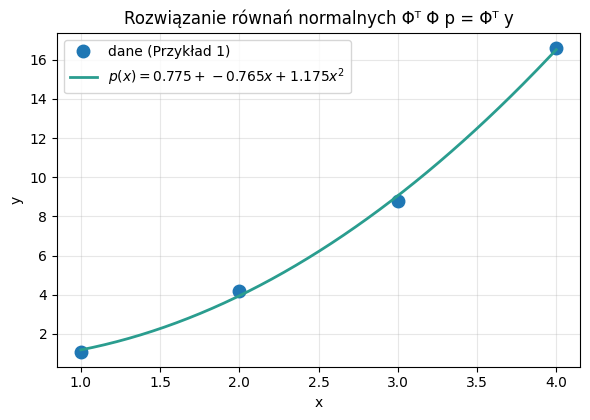

In [3]:
# Zamiast kolejnej tabeli liczb -- zobaczmy, co te wspolczynniki NAPRAWDE oznaczaja:
# dopasowana krzywa razem z danymi, z ktorych powstala.
fig, ax = plt.subplots(figsize=(6, 4.3))
xx = np.linspace(x.min(), x.max(), 200)
ax.plot(x, y, "o", ms=9, color="#1f77b4", label="dane (Przykład 1)")
ax.plot(xx, np.polyval(p[::-1], xx), color="#2a9d8f", lw=2,
        label=f"$p(x)={p[0]:.3f}+{p[1]:.3f}x+{p[2]:.3f}x^2$")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title("Rozwiązanie równań normalnych Φᵀ Φ p = Φᵀ y")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## 2. Uwarunkowanie rośnie z bazą naturalną, tak jak przy interpolacji

Przy interpolacji wielomianowej macierz Vandermonde'a robi się coraz gorzej
uwarunkowana wraz ze wzrostem liczby węzłów (patrz `ZI_INTERP_ILUSTR2`). Przy
aproksymacji dzieje się dokładnie to samo z macierzą równań normalnych $\Phi^T\Phi$ —
i to *podwójnie dotkliwie*, bo $\mathrm{cond}(\Phi^T\Phi) = \mathrm{cond}(\Phi)^2$
(mnożenie macierzy przez samą siebie **kwadratuje** jej liczbę uwarunkowania).

In [4]:
# Wiecej punktow (zeby bylo co dopasowywac przy wyzszych stopniach) -- 25 punktow na [0,1]
x_many = np.linspace(0, 1, 25)

stopnie = [1, 3, 5, 8, 12, 16]
cond_Phi = []
cond_A = []
for M in stopnie:
    Phi_M = np.column_stack([x_many**k for k in range(M + 1)])
    A_M = Phi_M.T @ Phi_M
    cond_Phi.append(np.linalg.cond(Phi_M))
    cond_A.append(np.linalg.cond(A_M))

# Potwierdzmy jawnie zaleznosc cond(Phi^T Phi) = cond(Phi)^2 -- tylko dla umiarkowanych
# M (do M=8): przy M=12/16 sama macierz jest juz TAK zle uwarunkowana (cond ~1e9-1e12),
# ze policzenie jej wlasnej liczby uwarunkowania przestaje byc numerycznie wiarygodne --
# to nie blad kodu, to naturalna granica arytmetyki double (~16 cyfr znaczacych).
for M, cP, cA in zip(stopnie, cond_Phi, cond_A):
    if M <= 8:
        assert np.isclose(cA, cP**2, rtol=0.05), f"M={M}: {cA} != {cP**2}"
print("Zaleznosc cond(A) = cond(Phi)^2 potwierdzona liczbowo dla M<=8 (przy wiekszym M",
      "sam pomiar cond() traci wiarygodnosc numeryczna) -- zobacz ponizszy wykres.")

Zaleznosc cond(A) = cond(Phi)^2 potwierdzona liczbowo dla M<=8 (przy wiekszym M sam pomiar cond() traci wiarygodnosc numeryczna) -- zobacz ponizszy wykres.


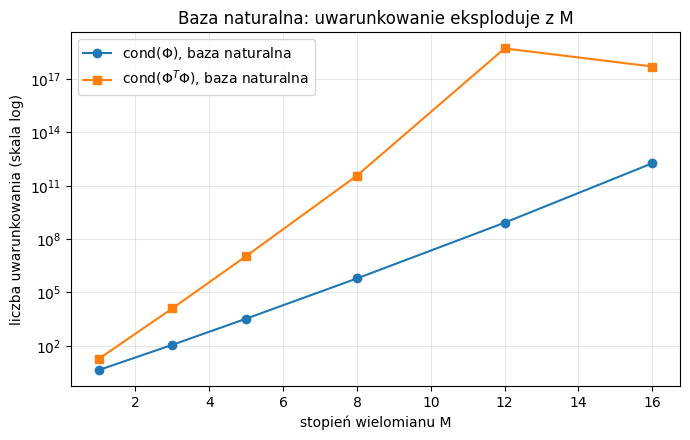

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogy(stopnie, cond_Phi, "o-", label=r"cond($\Phi$), baza naturalna")
ax.semilogy(stopnie, cond_A, "s-", label=r"cond($\Phi^T\Phi$), baza naturalna")
ax.set_xlabel("stopień wielomianu M")
ax.set_ylabel("liczba uwarunkowania (skala log)")
ax.set_title("Baza naturalna: uwarunkowanie eksploduje z M")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## 3. Baza ortogonalna: układ normalny staje się diagonalny

Rozwiązanie jest identyczne jak przy interpolacji: zamiast bazy naturalnej
$1, x, x^2, \dots$ użyjmy ciągu wielomianów **ortogonalnych na danym zbiorze węzłów**
(zbudowanych tu przez ortogonalizację Grama-Schmidta samej bazy naturalnej). Wtedy
$(\varphi_i, \varphi_j) = 0$ dla $i\neq j$ z definicji, więc $\Phi^T\Phi$ jest
**diagonalna** — układ rozpada się na $K$ niezależnych równań $a_{kk}\,p_k=b_k$, każde
trywialne do rozwiązania, i (co tu najważniejsze) dobrze uwarunkowane niezależnie od
stopnia.

In [6]:
def gram_schmidt_kolumny(Phi):
    """ZMODYFIKOWANA i UNORMOWANA ortogonalizacja Grama-Schmidta kolumn macierzy Phi
    (kazda kolumna to jedna funkcja bazowa sprobkowana w wezlach). Zwraca macierz Q o
    ORTONORMALNYCH kolumnach (ortogonalne I jednostkowej dlugosci), rozpinajacych ta
    sama przestrzen, co kolumny Phi.

    WAZNE (1): rzut liczymy wzgledem AKTUALNEGO (juz czesciowo zortogonalizowanego)
    wektora v, a nie wzgledem oryginalnej kolumny Phi[:,k] -- to jest dokladnie roznica
    miedzy 'klasyczna' a 'zmodyfikowana' wersja GS. Klasyczna wersja (rzut wzgledem
    oryginalu) jest matematycznie rownowazna, ale przy silnie skorelowanych (prawie
    rownoleglych) kolumnach -- a takie sa wlasnie wysokie potegi x na wspolnym
    przedziale -- gubi ortogonalnosc przez blad zaokraglenia. Zmodyfikowana wersja jest
    odpornsza.

    WAZNE (2): na koniec KAZDY wektor dzielimy przez jego wlasna norme (v /=
    ||v||). Bez tego kroku Q jest tylko ortogonalne, NIE ortonormalne -- kolumny maja
    dowolne, rozne dlugosci, a cond(Q) odzwierciedla wtedy przypadkowy stosunek tych
    dlugosci (co w praktyce nadal rosnie z M, tylko wolniej niz dla bazy naturalnej).
    Dopiero normalizacja daje cond(Q)=1 dla KAZDEGO M -- to jest to, co ma na mysli
    stwierdzenie 'uwarunkowanie przestaje zalezec od stopnia wielomianu'."""
    Q = np.zeros_like(Phi, dtype=float)
    for k in range(Phi.shape[1]):
        v = Phi[:, k].astype(float).copy()
        for j in range(k):
            proj = Q[:, j] @ v          # Q[:,j] ma juz norme 1, wiec proj = (Q_j, v)
            v -= proj * Q[:, j]
        Q[:, k] = v / np.linalg.norm(v)  # normalizacja -- bez niej Q nie jest ortonormalne
    return Q

cond_Q = []
cond_AQ = []
for M in stopnie:
    Phi_M = np.column_stack([x_many**k for k in range(M + 1)])
    Q_M = gram_schmidt_kolumny(Phi_M)
    A_Q = Q_M.T @ Q_M
    cond_Q.append(np.linalg.cond(Q_M))
    cond_AQ.append(np.linalg.cond(A_Q))
    # A_Q powinna byc (w granicach bledu numerycznego) macierza JEDNOSTKOWA (nie tylko
    # diagonalna) -- bo kolumny Q sa teraz ortonormalne: (phi_i,phi_j)=0 dla i!=j i
    # (phi_k,phi_k)=1. To znacznie mocniejsze i latwiejsze do sprawdzenia stwierdzenie
    # niz "jakas macierz diagonalna" -- stad jedna, ciasna tolerancja dla wszystkich M.
    assert np.allclose(A_Q, np.eye(M + 1), atol=1e-4), \
        f"M={M}: uklad nie jest (w przyblizeniu) macierza jednostkowa"
print("Ortonormalnosc Q (Q^T Q = I) potwierdzona dla wszystkich testowanych M -- zobacz",
      "mape cieplna ponizej.")

Ortonormalnosc Q (Q^T Q = I) potwierdzona dla wszystkich testowanych M -- zobacz mape cieplna ponizej.


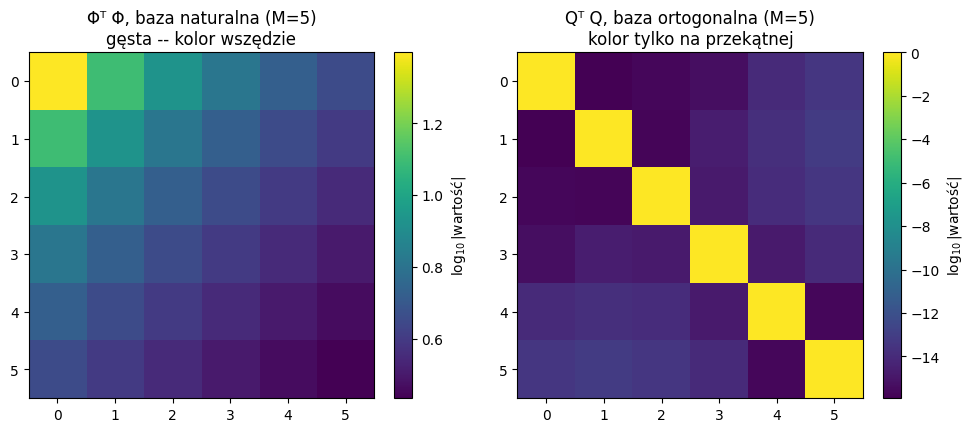

In [7]:
# Wizualizacja "na oko": macierz rownan normalnych dla bazy naturalnej kontra
# ortogonalnej (M=5) -- kolor = log10|wartosc|. Baza naturalna: macierz GESTA (prawie
# wszystkie elementy niezerowe i podobnej wielkosci -- trudno "rozdzielic"
# wspolczynniki). Baza ortogonalna: kolor tylko na PRZEKATNEJ -- uklad rozpada sie na
# niezalezne rownania.
M_vis = 5
Phi_vis = np.column_stack([x_many**k for k in range(M_vis + 1)])
A_vis = Phi_vis.T @ Phi_vis
Q_vis = gram_schmidt_kolumny(Phi_vis)
AQ_vis = Q_vis.T @ Q_vis

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
im0 = axes[0].imshow(np.log10(np.abs(A_vis) + 1e-300), cmap="viridis")
axes[0].set_title("Φᵀ Φ, baza naturalna (M=5)\ngęsta -- kolor wszędzie")
fig.colorbar(im0, ax=axes[0], label=r"$\log_{10}|$wartość$|$", fraction=0.046)
im1 = axes[1].imshow(np.log10(np.abs(AQ_vis) + 1e-300), cmap="viridis")
axes[1].set_title("Qᵀ Q, baza ortogonalna (M=5)\nkolor tylko na przekątnej")
fig.colorbar(im1, ax=axes[1], label=r"$\log_{10}|$wartość$|$", fraction=0.046)
fig.tight_layout()
plt.show()


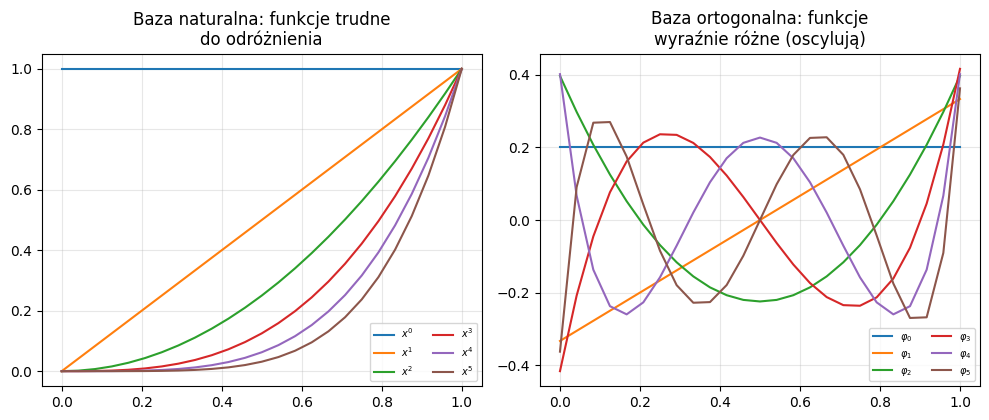

In [8]:
# I zeby bylo jasne SKAD sie ta roznica bierze: same funkcje bazowe. Baza naturalna
# x^0..x^5 na [0,1] wyglada niemal identycznie (wszystkie startuja podobnie i rosna
# monotonicznie) -- stad ich duza wzajemna "korelacja" i zle uwarunkowanie. Baza
# ortogonalna wyraznie oscyluje -- kazda funkcja niesie inna informacje.
fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))
for k in range(M_vis + 1):
    axes[0].plot(x_many, Phi_vis[:, k], label=f"$x^{k}$")
axes[0].set_title("Baza naturalna: funkcje trudne\ndo odróżnienia")
axes[0].legend(fontsize=7, ncol=2)
axes[0].grid(alpha=0.3)
for k in range(M_vis + 1):
    axes[1].plot(x_many, Q_vis[:, k], label=fr"$\varphi_{k}$")
axes[1].set_title("Baza ortogonalna: funkcje\nwyraźnie różne (oscylują)")
axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(alpha=0.3)
fig.tight_layout()
plt.show()


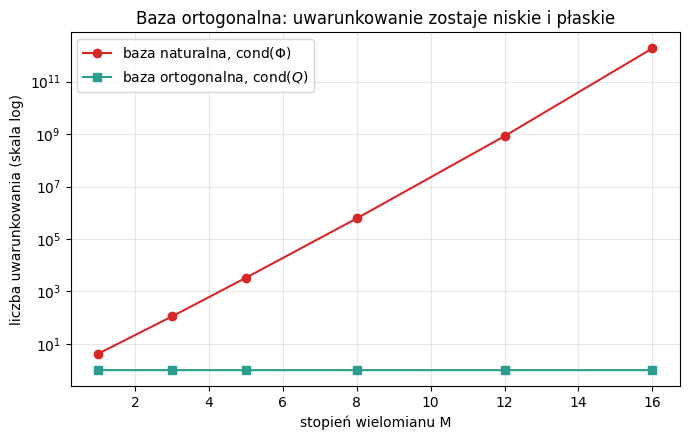

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.semilogy(stopnie, cond_Phi, "o-", color="#d62728", label=r"baza naturalna, cond($\Phi$)")
ax.semilogy(stopnie, cond_Q, "s-", color="#2a9d8f", label=r"baza ortogonalna, cond($Q$)")
ax.set_xlabel("stopień wielomianu M")
ax.set_ylabel("liczba uwarunkowania (skala log)")
ax.set_title("Baza ortogonalna: uwarunkowanie zostaje niskie i płaskie")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


## 4. Wzór na współczynniki przy bazie ortogonalnej: $p_k=(f,\varphi_k)/(\varphi_k,\varphi_k)$

Skoro układ jest diagonalny, każdy współczynnik liczy się niezależnie, bez odwracania
żadnej macierzy — dokładny odpowiednik przyrostowości Newtona przy interpolacji.

In [10]:
M = 5
Phi_M = np.column_stack([x_many**k for k in range(M + 1)])
Q_M = gram_schmidt_kolumny(Phi_M)

# Wspolrzedne y w tych samych wezlach (uzyjmy funkcji f(x) = sin(3x) + 0.1*x^2 jako
# przykladowych "danych" do dopasowania -- dowolna funkcja wystarczy do demonstracji)
y_many = np.sin(3 * x_many) + 0.1 * x_many**2

# Wzor jawny: p_k = (f, phi_k) / (phi_k, phi_k), gdzie (.,.) to iloczyn skalarny
# w wezlach (suma po probkach), a phi_k to k-ta KOLUMNA juz zortogonalizowanej bazy Q_M.
p_wzor = np.array([(y_many @ Q_M[:, k]) / (Q_M[:, k] @ Q_M[:, k]) for k in range(M + 1)])

# Kontrola: to samo powinno wyjsc z pelnego ukladu rownan normalnych Q^T Q p = Q^T y
p_uklad = np.linalg.solve(Q_M.T @ Q_M, Q_M.T @ y_many)
assert np.allclose(p_wzor, p_uklad)
print("Wzor jawny i pelny uklad rownan normalnych daja identyczny wynik: OK")

Wzor jawny i pelny uklad rownan normalnych daja identyczny wynik: OK


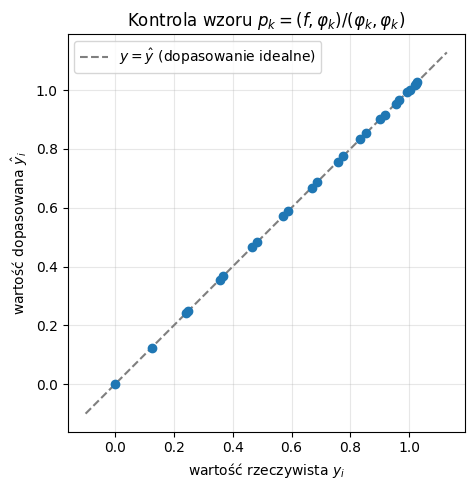

In [11]:
# Wykres kontrolny zamiast dwoch tabel liczb: wartosc dopasowana kontra rzeczywista
# w kazdym wezle. Idealne dopasowanie -- wszystkie punkty na przekatnej y=y_hat.
y_pred = Q_M @ p_wzor
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_many, y_pred, color="#1f77b4", zorder=5)
lims = [min(y_many.min(), y_pred.min()) - 0.1, max(y_many.max(), y_pred.max()) + 0.1]
ax.plot(lims, lims, "--", color="#7f7f7f", label="$y=\hat y$ (dopasowanie idealne)")
ax.set_xlabel("wartość rzeczywista $y_i$"); ax.set_ylabel(r"wartość dopasowana $\hat y_i$")
ax.set_title(r"Kontrola wzoru $p_k=(f,\varphi_k)/(\varphi_k,\varphi_k)$")
ax.legend(); ax.grid(alpha=0.3); ax.set_aspect("equal")
fig.tight_layout()
plt.show()


## Najważniejsze wnioski

- Układ równań normalnych $\Phi^T\Phi\,\mathbf p=\Phi^T\mathbf{\tilde y}$ liczy się
  wprost z danych — nic tu nie jest „magiczne", każdy element macierzy to konkretny
  iloczyn skalarny kolumn $\Phi$.
- Baza naturalna ($1,x,x^2,\dots$) ma dokładnie ten sam problem uwarunkowania co
  macierz Vandermonde'a przy interpolacji — i jest **gorszy w kwadracie**, bo
  $\mathrm{cond}(\Phi^T\Phi)=\mathrm{cond}(\Phi)^2$. Widać to też bezpośrednio: same
  funkcje bazowe $x^k$ na wspólnym przedziale są do siebie bardzo podobne.
- Baza ortogonalna sprawia, że układ normalny jest **diagonalny** (widać to wprost na
  mapie cieplnej macierzy) — dobrze uwarunkowany niezależnie od stopnia wielomianu, ze
  współczynnikami liczonymi jawnym wzorem $p_k=(f,\varphi_k)/(\varphi_k,\varphi_k)$, bez
  odwracania macierzy.

## Wykorzystywane funkcje

| Funkcja | Opis |
|---|---|
| `np.column_stack([...])` | Budowa macierzy bazy $\Phi$ z listy kolumn (funkcji bazowych spróbkowanych w węzłach) |
| `np.linalg.solve(A, b)` | Rozwiązanie układu równań liniowych $A\mathbf p=\mathbf b$ |
| `np.linalg.cond(M)` | Liczba uwarunkowania macierzy (stosunek największej do najmniejszej wartości osobliwej) |
| `plt.imshow(...)` | Mapa cieplna macierzy — wizualne porównanie struktury gęstej i diagonalnej |
| `np.polyfit(x, y, deg)` | Wbudowana, numerycznie stabilna metoda najmniejszych kwadratów (używana tu tylko do kontroli wyniku) |

## ĆWICZENIE

1. Zwiększ liczbę punktów `x_many` (np. do 50, dalej na `[0,1]`) i sprawdź na wykresie z
   sekcji 2, czy `cond(Phi)` dla bazy naturalnej rośnie jeszcze szybciej.
2. Sprawdź wzór $p_k=(f,\varphi_k)/(\varphi_k,\varphi_k)$ dla **innej** funkcji danych
   (np. `y_many = np.exp(x_many)`) i innego stopnia `M` — narysuj analogiczny wykres
   dopasowana-kontra-rzeczywista wartość.
3. **Rozszerzenie**: narysuj mapę cieplną (jak w sekcji 3) dla macierzy $\Phi^T\Phi$ i
   $Q^TQ$ przy $M=12$ zamiast $M=5$ — czy poza przekątną w prawym panelu pojawia się
   jakiś ślad koloru (a jeśli tak, dlaczego, biorąc pod uwagę wykres uwarunkowania z
   sekcji 3)?